In [33]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

model = joblib.load("shopping_model.pkl")
scaler = joblib.load("shopping_scaler.pkl")

In [34]:
df = pd.read_csv("online_shoppers_intention.csv")

df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

X = df_encoded.drop("Revenue", axis=1)
y = df_encoded["Revenue"]

In [35]:
model_features = X.columns  # OR use model.feature_names_in_ if available
X = X.reindex(columns=model_features, fill_value=0)

In [36]:
X_scaled = scaler.transform(X)

In [37]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
background = X_scaled[np.random.choice(X_scaled.shape[0], 100, replace=False)]
explainer = shap.Explainer(model, X_scaled_df)
shap_values = explainer(X_scaled)


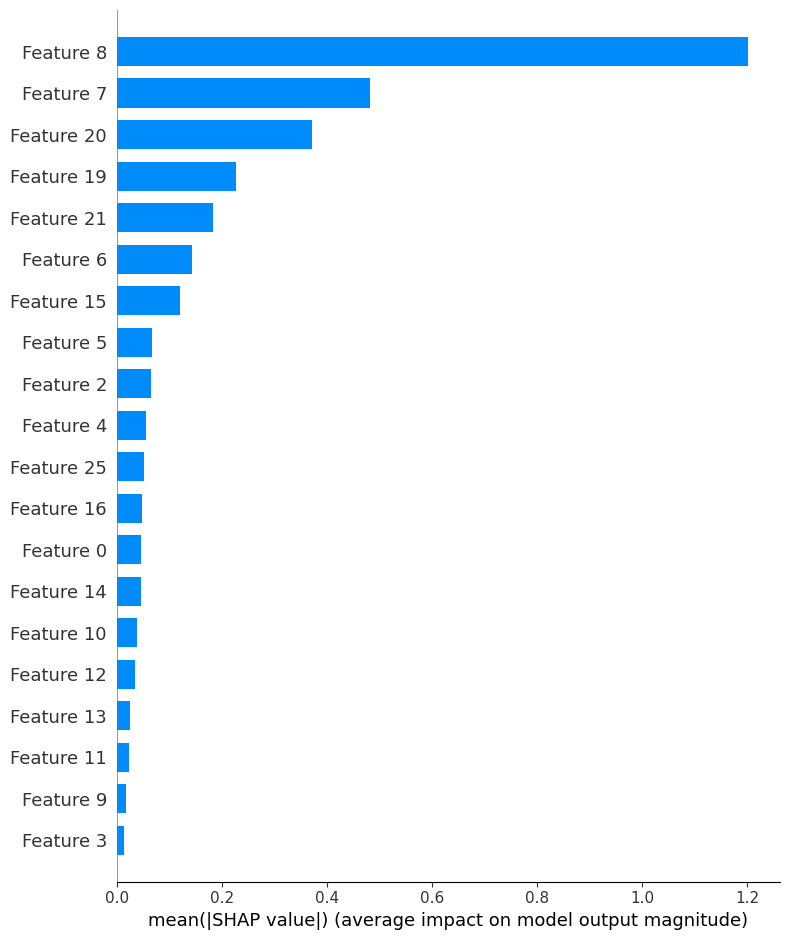

In [39]:
shap.summary_plot(shap_values, X_scaled_df, plot_type="bar")


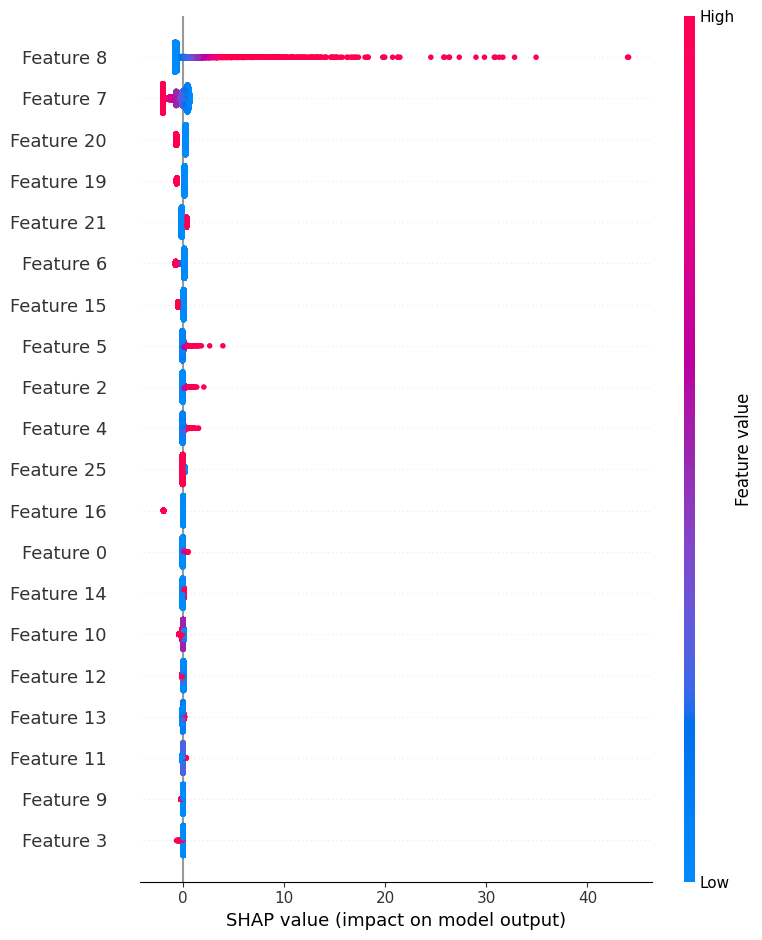

In [40]:
shap.summary_plot(shap_values, X_scaled_df)

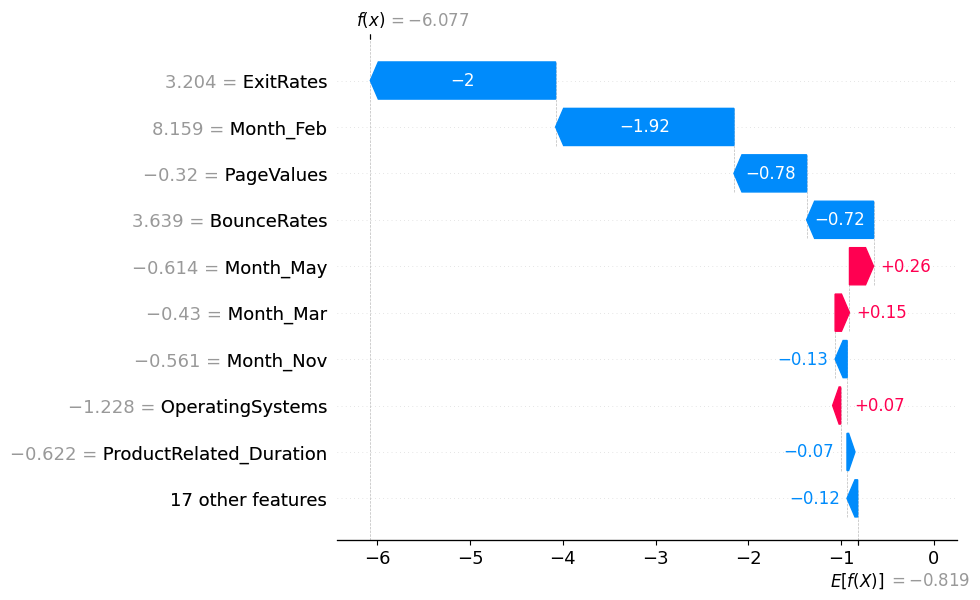

In [41]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values.values[0],
        base_values=shap_values.base_values[0],
        data=X_scaled[0],
        feature_names=X.columns
    )
)


In [42]:
shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP Value|": np.abs(shap_values.values).mean(axis=0)
}).sort_values(by="Mean |SHAP Value|", ascending=False)

print(shap_importance)

                          Feature  Mean |SHAP Value|
8                      PageValues           1.202738
7                       ExitRates           0.483117
20                      Month_May           0.371412
19                      Month_Mar           0.226627
21                      Month_Nov           0.183429
6                     BounceRates           0.142880
15                      Month_Dec           0.121536
5         ProductRelated_Duration           0.067005
2                   Informational           0.065994
4                  ProductRelated           0.055945
25  VisitorType_Returning_Visitor           0.051389
16                      Month_Feb           0.047856
0                  Administrative           0.047087
14                        Weekend           0.045915
10               OperatingSystems           0.037926
12                         Region           0.035889
13                    TrafficType           0.025109
11                        Browser           0.